# 03 — Random Forest (weekly silver volatility)

Random Forest on the **HAR features plus the EXOG cross-asset RV lags**. This is the
first model that can exploit volatility spillovers across asset classes (gold/silver
vol linkage, VIX as a global risk proxy), and it carries the same EXOG philosophy as
`weekly/04_random_forest.ipynb` on the returns side.

Hyperparameters are tuned on the validation split via a small grid, then the model is
re-fit on train+val. Features come from `volatility_weekly.csv` — run `00_features.ipynb`
first.


## Setup


In [1]:
import sys, os
sys.path.append(os.path.abspath('../../src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import ParameterGrid
from vol_utils import vol_evaluate, vol_period_metrics
from eval_utils import PERIODS
import warnings; warnings.filterwarnings('ignore')

SEED = 42
plt.rcParams['figure.figsize'] = (10, 4)

frame = pd.read_csv('../../data/processed/volatility_weekly.csv',
                    parse_dates=['Date']).set_index('Date')
train_df = frame[frame['split'] == 'train']
val_df   = frame[frame['split'] == 'val']
test_df  = frame[frame['split'] == 'test']
trval_df = frame[frame['split'] != 'test']

FEATS_HAR  = ['rv_w_lag1', 'rv_m_lag1', 'rv_q_lag1']
FEATS_EXOG = [c for c in frame.columns if c.endswith('_rv_lag1') and not c.startswith('silver')]
FEATS_ALL  = FEATS_HAR + FEATS_EXOG
print('features:', FEATS_ALL)


features: ['rv_w_lag1', 'rv_m_lag1', 'rv_q_lag1', 'gold_rv_lag1', 'copper_rv_lag1', 'usd_rv_lag1', 'sp500_rv_lag1', 'vix_rv_lag1', 'oil_rv_lag1']


## 1. Hyperparameter tuning

Small grid search over tree count / depth / leaf size. Each configuration is fit on the
train split and scored by RMSE on the validation split; the lowest-RMSE configuration
is kept.


In [2]:
y_tr = train_df['target']; y_v = val_df['target']

def tune_rf(X_tr, y_tr, X_v, y_v):
    grid = ParameterGrid({'n_estimators': [200, 400], 'max_depth': [3, 5, None],
                          'min_samples_leaf': [2, 5]})
    best = (np.inf, None)
    for p in grid:
        m = RandomForestRegressor(random_state=SEED, **p).fit(X_tr, y_tr)
        rmse = np.sqrt(mean_squared_error(y_v, m.predict(X_v)))
        if rmse < best[0]:
            best = (rmse, p)
    return best[1]

rf_best = tune_rf(train_df[FEATS_ALL], y_tr, val_df[FEATS_ALL], y_v)
print('RF best params:', rf_best)


RF best params: {'max_depth': 3, 'min_samples_leaf': 2, 'n_estimators': 200}


## 2. Refit on train+val and evaluate

The best configuration is re-fit on train+val combined, then scored once on the test
set.


In [3]:
y_test    = test_df['target'].values
prev_test = test_df['rv_w_lag1'].values

rf = RandomForestRegressor(random_state=SEED, **rf_best).fit(trval_df[FEATS_ALL], trval_df['target'])
rf_pred = rf.predict(test_df[FEATS_ALL])

results = [vol_evaluate('RF (HAR+EXOG)', y_test, rf_pred, prev_test)]


RF (HAR+EXOG)                   RMSE=0.03518  MAE=0.01832  R2=+0.145  DCA=0.680


## 3. Feature importance

Mean decrease in impurity (MDI) across the forest — which features the trees actually
split on. The HAR lags are expected to dominate; the question is whether any EXOG
cross-asset RV earns non-trivial importance, which would be direct evidence of
volatility spillover.


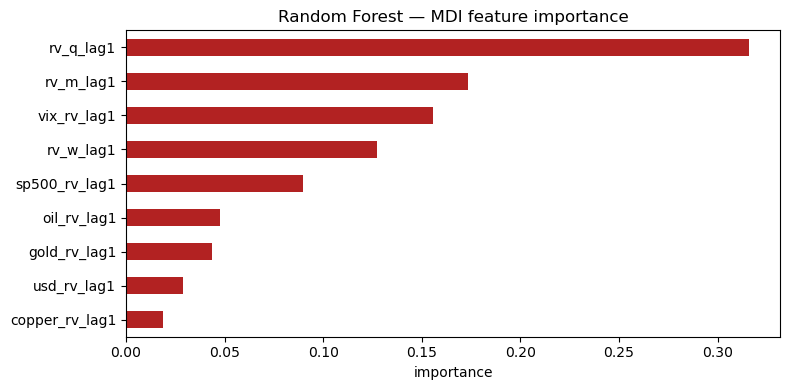

rv_q_lag1         0.3158
rv_m_lag1         0.1733
vix_rv_lag1       0.1558
rv_w_lag1         0.1274
sp500_rv_lag1     0.0895
oil_rv_lag1       0.0474
gold_rv_lag1      0.0435
usd_rv_lag1       0.0287
copper_rv_lag1    0.0186
dtype: float64

In [4]:
imp = pd.Series(rf.feature_importances_, index=FEATS_ALL).sort_values()
fig, ax = plt.subplots(figsize=(8, 4))
imp.plot.barh(ax=ax, color='firebrick')
ax.set_title('Random Forest — MDI feature importance'); ax.set_xlabel('importance')
plt.tight_layout(); plt.show()
imp.sort_values(ascending=False).round(4)


## 4. Sub-period breakdown

RMSE and DCA split by calendar year, using the shared `PERIODS` definition.


In [5]:
period_rf = vol_period_metrics(y_test, rf_pred, prev_test, test_df.index, PERIODS)
period_rf.to_csv('../../data/processed/period_rf_volatility.csv')
period_rf.round(4)


,n,RMSE,DCA
Period,,,
2023 (choppy),52,0.0147,0.6923
2024 (bull start),52,0.0172,0.7308
2025 (bull run),52,0.0245,0.6346
2026 (YTD),19,0.0914,0.6316
── Full test ──,175,0.0352,0.6800


## 5. Save outputs

- `metrics_rf_volatility.csv` — Random Forest headline metrics
- `pred_rf_volatility.csv` — test-set predictions, consumed by `evaluation.ipynb`


In [6]:
pd.DataFrame(results).to_csv('../../data/processed/metrics_rf_volatility.csv', index=False)

pred_rf = pd.DataFrame({'actual': y_test, 'prev': prev_test, 'rf': rf_pred}, index=test_df.index)
pred_rf.to_csv('../../data/processed/pred_rf_volatility.csv', index_label='Date')
print('Saved metrics_rf_volatility.csv + pred_rf_volatility.csv')
pd.DataFrame(results).round(5)


Saved metrics_rf_volatility.csv + pred_rf_volatility.csv


,model,rmse,mae,r2,dca
0,RF (HAR+EXOG),0.03518,0.01832,0.1446,0.68
